# Distillation Column Soft-Sensor
## EDA & Feature Engineering (Hybrid Traditional ML + RNN)

This notebook explores the distillation column time-series dataset and engineers features for both traditional ML and RNN modeling.

**Objective**: Predict product purity (top/bottom composition) from process variables.

**Data**: Time series with 0.1h intervals (10 samples per hour)

**Approach**:
- **Primary**: Traditional ML (XGBoost) with lagged features
- **Stretch**: RNN (LSTM) with sequence reshaping

**Timeline**:
- Part 1: Setup & Data Loading
- Part 2: Exploratory Data Analysis (EDA)
- Part 3: Time-Series Analysis (ACF, stationarity, seasonality)
- Part 4: Data Cleaning & Preprocessing
- Part 5: Feature Engineering (Traditional ML path)
- Part 6: RNN Data Preparation (Stretch goal)
- Part 7: Final Summary & Export

### 1. Setup & Data Loading

In [47]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Time series specific
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

#### 1.1. Load and check data

In [ ]:
from pathlib import Path

ROOT = Path.cwd().parent

df_path = ROOT / "data" / "dataset_distill.csv"

In [49]:
df = pd.read_csv(df_path, sep=';')

In [50]:
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(10))

Dataset shape: (4408, 21)

First few rows:
   Pressure      T1      T2      T3      T4      T5      T6      T7      T8  \
0      1.01  350.89  350.95  351.01  351.08  351.16  351.26  351.38  351.54   
1      1.01  350.86  350.91  350.96  351.02  351.09  351.17  351.28  351.43   
2      1.01  350.85  350.89  350.93  350.99  351.05  351.13  351.23  351.37   
3      1.01  350.84  350.88  350.92  350.97  351.03  351.11  351.21  351.34   
4      1.01  350.83  350.87  350.91  350.96  351.02  351.09  351.18  351.31   
5      1.01  350.83  350.86  350.91  350.95  351.01  351.08  351.17  351.29   
6      1.01  350.83  350.86  350.90  350.95  351.01  351.07  351.16  351.28   
7      1.01  350.83  350.86  350.90  350.95  351.00  351.07  351.16  351.27   
8      1.01  350.82  350.86  350.90  350.94  351.00  351.07  351.15  351.27   
9      1.01  350.82  350.86  350.90  350.94  351.00  351.06  351.15  351.26   

       T9  ...     T11     T12     T13     T14    L     V    D    B    F  \
0  351.78  

In [51]:
df.isnull().sum()

Pressure                 0
T1                       0
T2                       0
T3                       0
T4                       0
T5                       0
T6                       0
T7                       0
T8                       0
T9                       0
T10                      0
T11                      0
T12                      0
T13                      0
T14                      0
L                        0
V                        0
D                        0
B                        0
F                        0
Ethanol concentration    0
dtype: int64

In [52]:
df.dtypes

Pressure                 float64
T1                       float64
T2                       float64
T3                       float64
T4                       float64
T5                       float64
T6                       float64
T7                       float64
T8                       float64
T9                       float64
T10                      float64
T11                      float64
T12                      float64
T13                      float64
T14                      float64
L                         object
V                         object
D                          int64
B                          int64
F                          int64
Ethanol concentration    float64
dtype: object

In [53]:
# Convert columns L and V to int64

for col in ['L', 'V']:
    df[col] = df[col].astype(str).str.replace(',', '.', regex=False)
    df[col] = pd.to_numeric(df[col], errors='coerce')

In [54]:
df.dtypes

Pressure                 float64
T1                       float64
T2                       float64
T3                       float64
T4                       float64
T5                       float64
T6                       float64
T7                       float64
T8                       float64
T9                       float64
T10                      float64
T11                      float64
T12                      float64
T13                      float64
T14                      float64
L                        float64
V                        float64
D                          int64
B                          int64
F                          int64
Ethanol concentration    float64
dtype: object

#### 1.2. Create Time Index (for time-series analysis)

In [55]:
# Create time index: 0.1h intervals starting from 0
time_interval = 0.1  # hours
df['time_hours'] = df.index * time_interval

print(f"Time span: {df['time_hours'].min():.1f}h to {df['time_hours'].max():.1f}h")
print(f"Total duration: {df['time_hours'].max():.1f} hours ({df['time_hours'].max()/24:.2f} days)")
print(f"\nFirst 5 timestamps:")
print(df[['time_hours']].head())

Time span: 0.0h to 440.7h
Total duration: 440.7 hours (18.36 days)

First 5 timestamps:
   time_hours
0         0.0
1         0.1
2         0.2
3         0.3
4         0.4


### 2. Exploratory Data Analysis (EDA)

#### 2.1. Dataset Overview

In [56]:
# Statistical summary
print("Statistical Summary:")
print(df.describe())

Statistical Summary:
       Pressure           T1           T2           T3           T4  \
count   4408.00  4408.000000  4408.000000  4408.000000  4408.000000   
mean       1.01   351.029049   351.409363   352.066202   352.828578   
std        0.00     0.334105     1.125225     2.671189     3.788418   
min        1.01   350.760000   350.770000   350.770000   350.790000   
25%        1.01   350.820000   350.860000   350.900000   350.950000   
50%        1.01   350.900000   350.990000   351.100000   351.260000   
75%        1.01   351.080000   351.390000   351.822500   352.410000   
max        1.01   352.320000   356.030000   364.970000   368.600000   

                T5           T6           T7           T8           T9  ...  \
count  4408.000000  4408.000000  4408.000000  4408.000000  4408.000000  ...   
mean    353.910204   355.214270   356.453975   357.539902   358.484004  ...   
std       4.986453     6.251028     7.119853     7.620257     7.882159  ...   
min     350.800000   35

In [57]:
# Basic info about the dataset
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nDataset Shape:", df.shape)
print(f"Time points: {df.shape[0]}")
print(f"Sampling interval: {time_interval}h")
print(f"Total features: {df.shape[1]-1}")

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4408 entries, 0 to 4407
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Pressure               4408 non-null   float64
 1   T1                     4408 non-null   float64
 2   T2                     4408 non-null   float64
 3   T3                     4408 non-null   float64
 4   T4                     4408 non-null   float64
 5   T5                     4408 non-null   float64
 6   T6                     4408 non-null   float64
 7   T7                     4408 non-null   float64
 8   T8                     4408 non-null   float64
 9   T9                     4408 non-null   float64
 10  T10                    4408 non-null   float64
 11  T11                    4408 non-null   float64
 12  T12                    4408 non-null   float64
 13  T13                    4408 non-null   float64
 14  T14                    4408 non-null   flo

#### 2.2. Target Variable Analysis

In [58]:
target_col = 'Ethanol concentration'

print(f"Target Variable: {target_col}")
print(f"\nTarget Statistics:")
print(df[target_col].describe())

Target Variable: Ethanol concentration

Target Statistics:
count    4408.000000
mean        0.792205
std         0.076441
min         0.538190
25%         0.761890
50%         0.817520
75%         0.850280
max         0.891760
Name: Ethanol concentration, dtype: float64


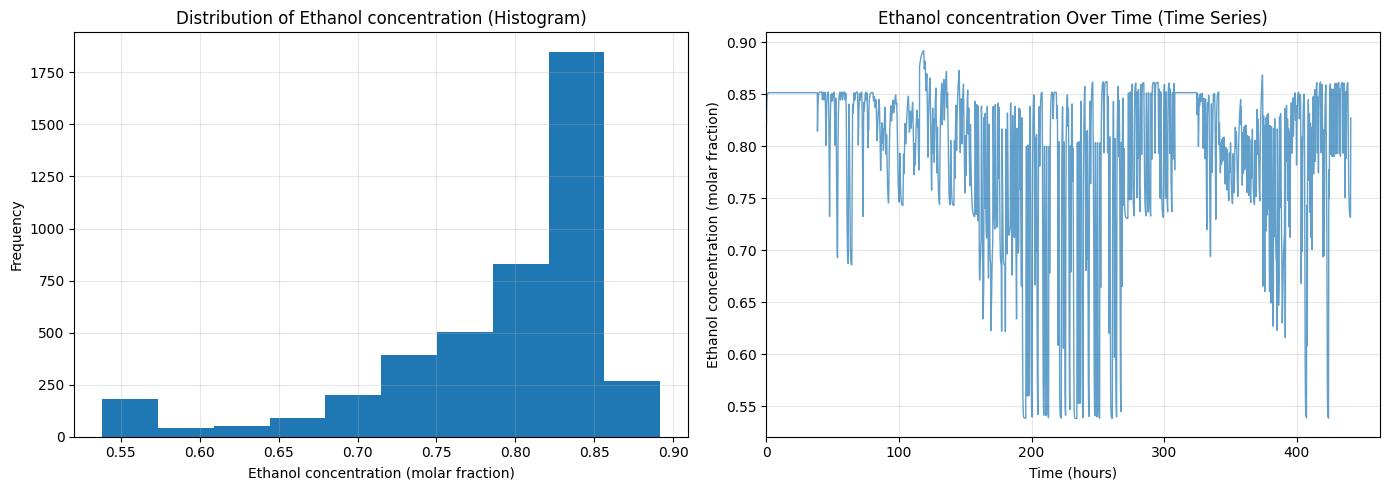

In [59]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[target_col])
axes[0].set_xlabel('Ethanol concentration (molar fraction)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Ethanol concentration (Histogram)')
axes[0].grid(alpha=0.3)

# Time series plot
axes[1].plot(df['time_hours'], df[target_col], linewidth=1, alpha=0.7)
axes[1].set_xlabel('Time (hours)')
axes[1].set_ylabel('Ethanol concentration (molar fraction)')
axes[1].set_title('Ethanol concentration Over Time (Time Series)')
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0,)

plt.tight_layout()
plt.show()

### 2.4 Feature Distributions Analysis

In [60]:
# Get all input features
feature_cols = [col for col in df.columns if col != target_col]

print(f"Number of input features: {len(feature_cols)}")


Number of input features: 21


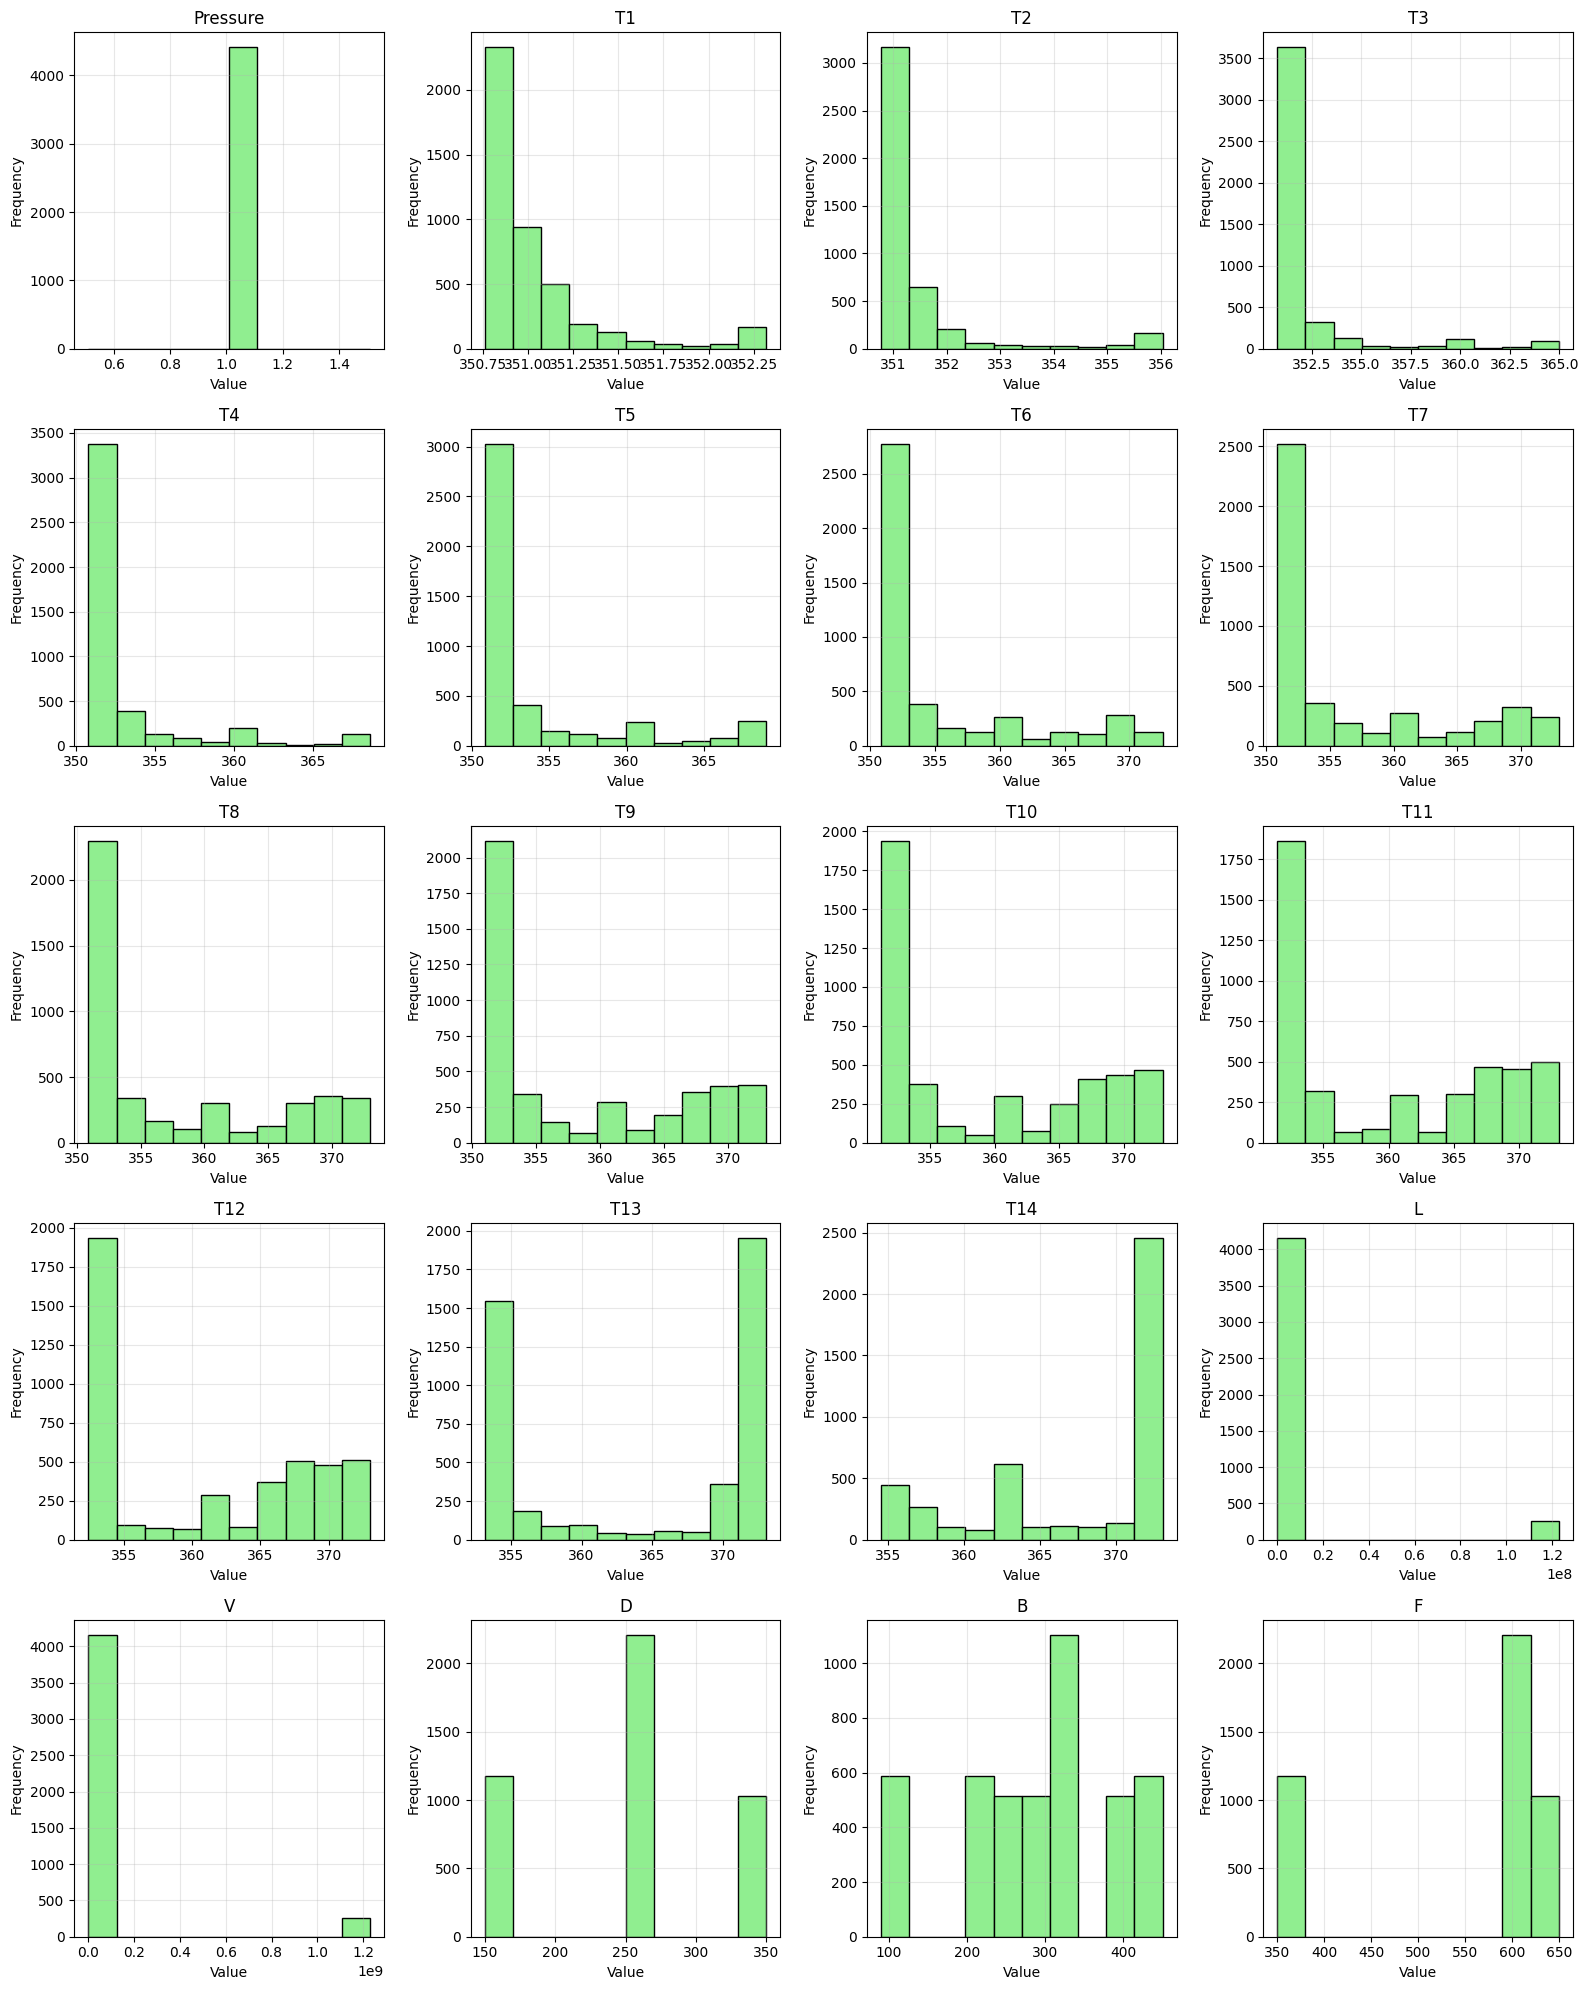

In [61]:
# Plot distributions of all features (excluding time_hours for clarity)
feature_cols_to_plot = [col for col in feature_cols if col != 'time_hours']
n_features = len(feature_cols_to_plot)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(feature_cols_to_plot):
    axes[idx].hist(df[col], color='lightgreen', edgecolor='black')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [62]:
# Extract hour of day from time_hours (to be better explored latter in the data preprocessing)
df['hour_of_day'] = (df['time_hours'] % 24).astype(int)

In [63]:
df.head()

,Pressure,T1,T2,T3,T4,T5,T6,T7,T8,T9,...,T13,T14,L,V,D,B,F,Ethanol concentration,time_hours,hour_of_day
0,1.01,350.89,350.95,351.01,351.08,351.16,351.26,351.38,351.54,351.78,...,363.77,371.47,780.0,1040.0,260,340,600,0.82076,0.0,0
1,1.01,350.86,350.91,350.96,351.02,351.09,351.17,351.28,351.43,351.66,...,362.20,370.98,780.0,1040.0,260,340,600,0.83253,0.1,0
2,1.01,350.85,350.89,350.93,350.99,351.05,351.13,351.23,351.37,351.58,...,360.16,370.10,780.0,1040.0,260,340,600,0.83953,0.2,0
3,1.01,350.84,350.88,350.92,350.97,351.03,351.11,351.21,351.34,351.53,...,358.45,368.99,780.0,1040.0,260,340,600,0.84366,0.3,0
4,1.01,350.83,350.87,350.91,350.96,351.02,351.09,351.18,351.31,351.49,...,357.23,367.81,780.0,1040.0,260,340,600,0.84622,0.4,0


### 2.5 Correlation Analysis

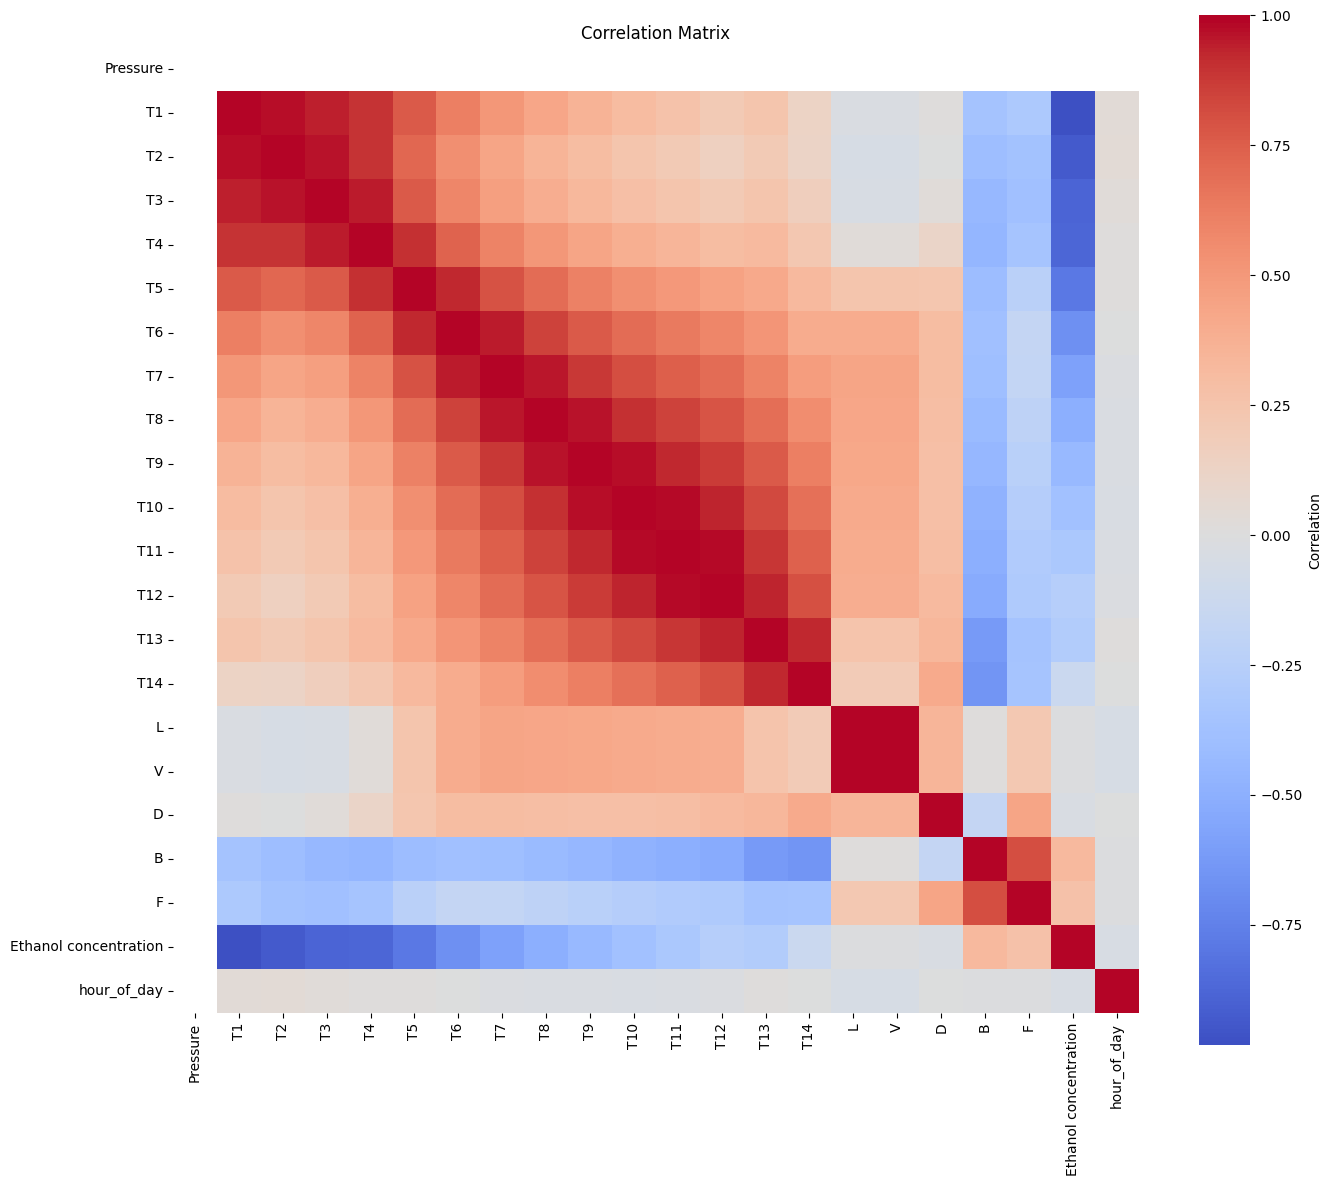

In [64]:
# Correlation matrix
corr_cols = [col for col in df.columns if col != 'time_hours']
corr_matrix = df[corr_cols].corr()

# Visualize correlations
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, 
            square=True, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

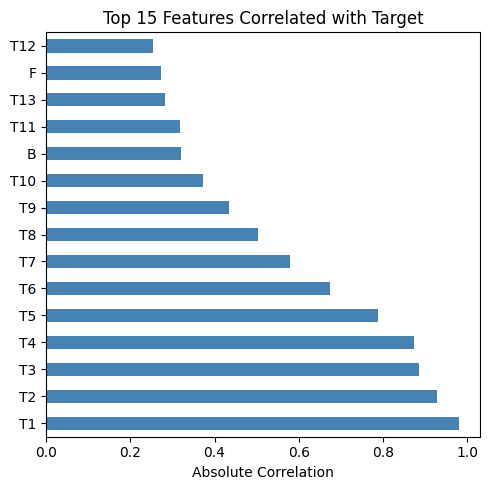

In [65]:
# Correlation with target variable
target_corr = corr_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)
plt.figure(figsize=(5, 5))
target_corr.head(15).plot(kind='barh', color='steelblue')
plt.xlabel('Absolute Correlation')
plt.title(f'Top 15 Features Correlated with Target')
plt.tight_layout()
plt.show()

### 2.6. Time series analysis

#### 2.6.1. Autocorrelation Function (ACF) Analysis

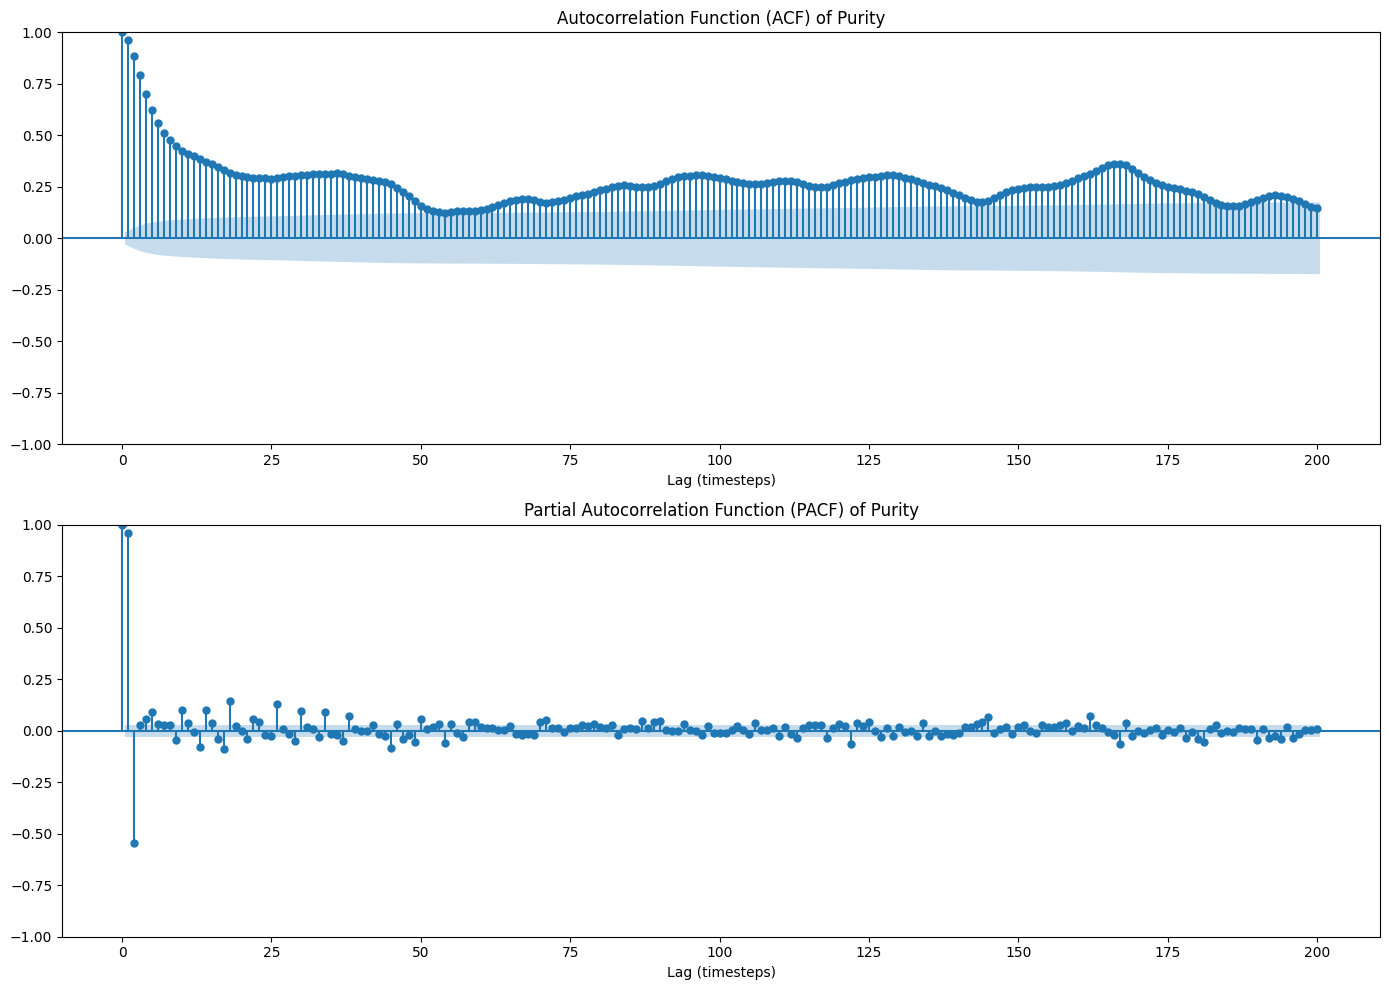

In [66]:
# ACF shows how past values correlate with future values and this is critical for choosing:
# - How many lags to use in traditional ML (lagged features)
# - What sequence length to use for RNN

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ACF
plot_acf(df[target_col], lags=200, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF) of Purity')
axes[0].set_xlabel('Lag (timesteps)')

# PACF
plot_pacf(df[target_col], lags=200, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF) of Purity')
axes[1].set_xlabel('Lag (timesteps)')

plt.tight_layout()
plt.show()

ACF/PACF Interpretation:
- The target has memory of 6 hours (~60 timesteps) [ACF]
- But most of the responses happens within 24 minutes (4 timesteps) [PACF]

Conclusion regarging the lags:
  - Traditional ML: to use lags=[1, 2, 5, 100]
  - RNN: to use sequence_length=60

### 2.6.2. Stationarity Test (Augmented Dickey-Fuller)

In [67]:
# Stationarity: Does the mean/variance change over time?
# Important for time-series models (RNN learns patterns better with stationary data)

p_value = adfuller(df[target_col])[1] 
print(f'p-value = {p_value}')
   
if p_value <= 0.05:
    print(f"STATIONARY (reject null hypothesis)")

else:
    print(f"NON-STATIONARY (fail to reject null hypothesis)")


p-value = 2.1451952649133202e-08
STATIONARY (reject null hypothesis)


#### 2.6.3 Seasonal Decomposition


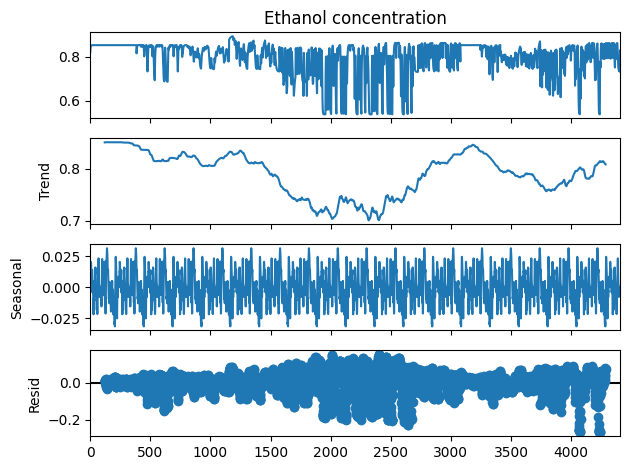

In [68]:
# Assuming a 24-hour seasonality based on your 0.1h sampling
result_add = seasonal_decompose(df[target_col], model='additive', period=240)
result_add.plot();

- ADF test p-value ≈ 0 → suggests STATIONARY (reject null hypothesis), however visual decomposition shows clear TREND → suggests NON-STATIONARY.

- Seasonal decomposition: Shows clear trend and seasonality around 24h (240 timesteps) 

## 3. Data Cleaning & Preprocessing

### 3.1 Handle Missing Values

In [69]:
# Create a copy for cleaning
df_clean = df.copy()

df_clean = df_clean.interpolate(method='linear')

print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")

Original shape: (4408, 23)
Cleaned shape: (4408, 23)
Rows removed: 0


#### 3.2 Handle Outliers

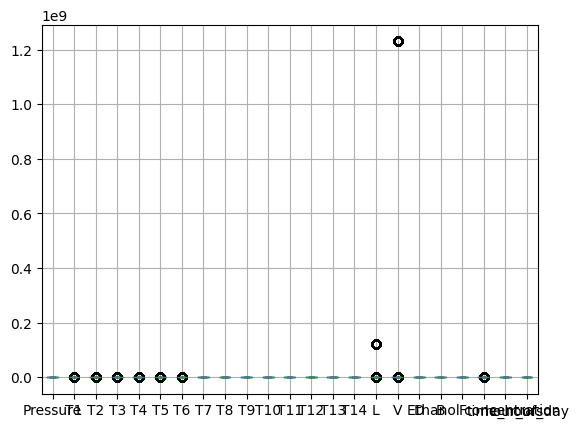

In [70]:
df.boxplot();

In [71]:
# Cap outliers at IQR bounds for features 'L' and 'V'
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[col].clip(lower=lower_bound, upper=upper_bound)

outliers_cols = ['L', 'V']

for col in outliers_cols:
    df_clean[col] = cap_outliers(df_clean, col)

print(f"Shape after outlier handling: {df_clean.shape}")

Shape after outlier handling: (4408, 23)


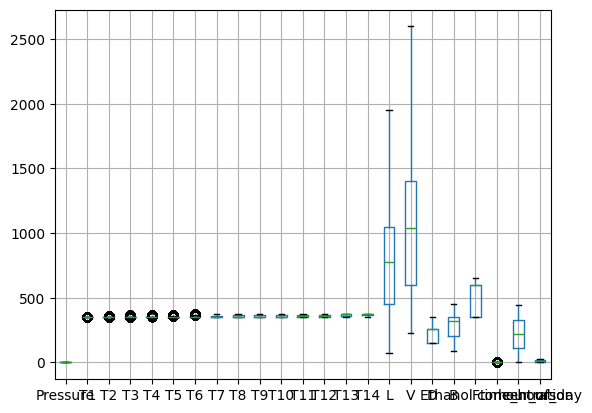

In [72]:
df_clean.boxplot();

### 4. Feature Engineering

#### 4.1 Create Lagged Features

In [73]:
def create_lagged_features(data, columns, lags):
    """
    Create lagged features.
    Example: if lag=1, feature_lag1 = value from 0.1h ago
    """
    df_lagged = data.copy()
    
    for col in columns:
        for lag in lags:
            df_lagged[f'{col}_lag{lag}'] = df_lagged[col].shift(lag)
    
    return df_lagged

lags_to_use = [1, 5, 10, 30, 60, 240] 
lagged_cols = target_corr.head(5).index  # Starting with top 5 correlated features

df_clean = create_lagged_features(df_clean, lagged_cols, lags=lags_to_use)

print(f"Shape after lagging: {df_clean.shape}")
print(f"New lagged features: {len(lagged_cols) * len(lags_to_use)}")

Shape after lagging: (4408, 53)
New lagged features: 30


### 4.2 Create Rolling Statistics


In [74]:
def create_rolling_features(data, columns, window):
    """
    Create rolling mean, std, min, max.
    Example: window=5 means average of last 5 samples (0.5h)
    """
    df_rolling = data.copy()
    
    for col in columns:
        df_rolling[f'{col}_rolling_mean_{window}'] = df_rolling[col].rolling(window=window).mean()

    
    return df_rolling


rolling_cols = target_corr.head(5).index 
df_clean = create_rolling_features(df_clean, rolling_cols, window=5)

print(f"Shape after rolling features: {df_clean.shape}")

Shape after rolling features: (4408, 58)


#### 4.3 Handle NaNs from Feature Engineering


In [75]:
# Lagging and rolling windows create NaNs at the beginning

df_clean = df_clean.dropna()

print(f"NaNs after cleanup: {df_clean.isnull().sum().sum()}")
print(f"Shape after removing NaNs: {df_clean.shape}")
print(f"Rows retained: {len(df_clean)} ({len(df_clean)/len(df)*100:.1f}%)")

NaNs after cleanup: 0
Shape after removing NaNs: (4168, 58)
Rows retained: 4168 (94.6%)


### 5. Cyclic Encoding for time-of-day (sin/cos transformation)

In [76]:
# Extract hour of day from time_hours
df_clean['hour_of_day'] = (df_clean['time_hours'] % 24)

print("Extracted time components:")
print(df_clean[['time_hours', 'hour_of_day']].head(10))

Extracted time components:
     time_hours  hour_of_day
240        24.0          0.0
241        24.1          0.1
242        24.2          0.2
243        24.3          0.3
244        24.4          0.4
245        24.5          0.5
246        24.6          0.6
247        24.7          0.7
248        24.8          0.8
249        24.9          0.9


In [77]:
### Apply Sin/Cos Encoding

def apply_cyclic_encoding(data, time_column, period):
    """
    Apply sin/cos encoding to cyclic variables.
    
    Parameters:
    - data: DataFrame
    - time_column: column name to encode
    - period: cycle length (e.g., 24 for hours in a day)
    
    Returns:
    - DataFrame with sin/cos features added
    """
    df_encoded = data.copy()
    
    # Apply sin and cos transformations
    df_encoded[f'{time_column}_sin'] = np.sin(2 * np.pi * df_encoded[time_column] / period)
    df_encoded[f'{time_column}_cos'] = np.cos(2 * np.pi * df_encoded[time_column] / period)
    
    return df_encoded

# Apply cyclic encoding to hour of day (period=24)
df_clean = apply_cyclic_encoding(df_clean, 'hour_of_day', period=24)

print("\nCyclic encoding applied:")
print(df_clean[['hour_of_day', 'hour_of_day_sin', 'hour_of_day_cos']].head(10))


Cyclic encoding applied:
     hour_of_day  hour_of_day_sin  hour_of_day_cos
240          0.0         0.000000         1.000000
241          0.1         0.026177         0.999657
242          0.2         0.052336         0.998630
243          0.3         0.078459         0.996917
244          0.4         0.104528         0.994522
245          0.5         0.130526         0.991445
246          0.6         0.156434         0.987688
247          0.7         0.182236         0.983255
248          0.8         0.207912         0.978148
249          0.9         0.233445         0.972370


In [78]:
# Update feature list: DROP raw time variables, KEEP encoded versions
features_to_drop = ['time_hours', 'time_index', 'hour_of_day', 'Pressure'] # also removing pressure once it's constant
features_to_keep = [col for col in df_clean.columns if col not in features_to_drop + [target_col]]

print(f"\nFinal feature list (for modeling):")
print(f"Total features: {len(features_to_keep)}")
print(f"\nIncludes:")
print(f"  - Original sensor data")
print(f"  - Cyclic encoded time: hour_of_day_sin, hour_of_day_cos")
print(f"  - Lagged features and rolling stats")


Final feature list (for modeling):
Total features: 56

Includes:
  - Original sensor data
  - Cyclic encoded time: hour_of_day_sin, hour_of_day_cos
  - Lagged features and rolling stats


### 6. Remove Highly Correlated Features


In [79]:
def find_correlated_features(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    correlated_features = [
        column for column in upper_triangle.columns
        if any(upper_triangle[column] > threshold)
    ]
    
    return correlated_features

# Find highly correlated features
high_corr_features = find_correlated_features(df_clean[features_to_keep], threshold=0.95)

print(f"Highly correlated features (>0.95): {len(high_corr_features)}")

Highly correlated features (>0.95): 26


In [80]:
features_to_keep = list(set(features_to_keep) - set(high_corr_features))
len(features_to_keep)

30

#### 6.1 Prepare dataset to ML models

In [81]:
# Separate features and target
X_ml = df_clean[features_to_keep]
y_ml = df_clean[target_col]

print(f"Features (X) shape: {X_ml.shape}")
print(f"Target (y) shape: {y_ml.shape}")

Features (X) shape: (4168, 30)
Target (y) shape: (4168,)


### 7. Final Summary & Export
#### 7.1. Save Data for Modeling


In [83]:
# Save cleaned data for ML modeling
DATA_DIR = ROOT / "data"

df_clean.to_csv(DATA_DIR /'distillation_cleaned_ml.csv', index=False)
X_ml.to_csv(DATA_DIR / 'X_ml_features.csv', index=False)
y_ml.to_csv(DATA_DIR / 'y_ml_target.csv', index=False)

print("✅ ML dataset saved:")
print("  - data/distillation_cleaned_ml.csv")
print("  - data/X_ml_features.csv")
print("  - data/y_ml_target.csv")


✅ ML dataset saved:
  - data/distillation_cleaned_ml.csv
  - data/X_ml_features.csv
  - data/y_ml_target.csv


#### 7.2 Key Insights & Next Steps

📝 KEY INSIGHTS FROM TIME-SERIES EDA WITH CYCLIC ENCODING:

1. DATA QUALITY:
   - Dataset with no missing values and some outliers in columns 'V' and 'L', that were addressed in the
   cleaning steps
   - Dataset is composed o synthetic data, so the good quality was expected before starting the project

2. TEMPORAL PATTERNS:
   - ACF suggests lag/sequence length of 60 timesteps (6 hours)
   - Stationarity: process is NOT stationary and presents trend when decomposition is applied
   - Cyclic patterns also verified in the decomposition step. Added cyclic features to investigate. 

4. FEATURE ENGINEERING:
   - Raw features: 21
   - Engineered + raw features - correlated features: 30 
   - Cyclic features: 2 (hour_sin, hour_cos)

📋 NEXT STEPS:

2 - TRADITIONAL ML MODELING:
  1. Start with 03_modeling.ipynb
  2. Train XGBoost with cyclic time features
  3. Compare with Random Forest, LinearRegression
  4. Hyperparameter tune best model
  5. Evaluate on test set
  6. Check feature importance → see if time matters!

3 - DEPLOYMENT:
  1. Create FastAPI endpoint
  2. Build Streamlit dashboard
  3. Include time-of-day selector (use cyclic encoding!)
  4. Document in README

4 - RNN EXTENSION:
  1. Uncomment RNN code in Part 6
  2. Create 03_lstm_modeling.ipynb
  3. Build LSTM model (will learn cyclic patterns automatically)
  4. Compare LSTM vs XGBoost performance

